# Laporan Praktikum Machine Learning
## Pertemuan 4: Classification - Logistic Regression & Decision Tree

* **Nama**: Ardian Syaputra
* **NIM**: 105841107823

---

## 🛠️ Setup Environment & Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.datasets import load_breast_cancer, load_wine

# Setting visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Library Classification berhasil di-import!")

Library Classification berhasil di-import!


Task 1: Load Data, Train Model & Evaluasi Metrics

=== Info Dataset Breast Cancer ===
Jumlah sampel : 569
Jumlah fitur  : 30

Distribusi Kelas (0 = Malignant/Ganas, 1 = Benign/Jinak):
target
1    357
0    212
Name: count, dtype: int64

=== Evaluasi Logistic Regression (Breast Cancer) ===
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861


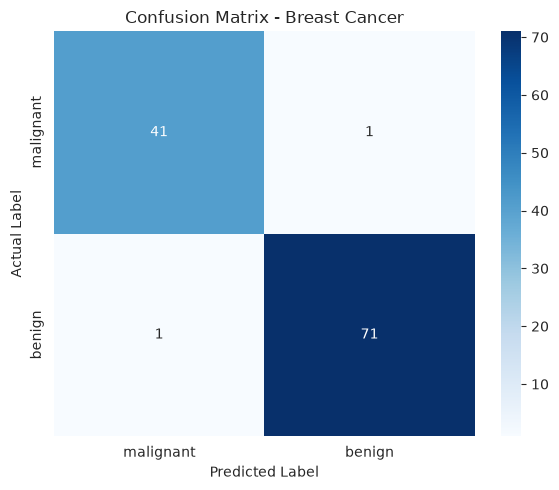

In [2]:
# 1. Load Dataset Breast Cancer
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

df_cancer = pd.DataFrame(X, columns=cancer.feature_names)
df_cancer['target'] = y

print("=== Info Dataset Breast Cancer ===")
print(f"Jumlah sampel : {X.shape[0]}")
print(f"Jumlah fitur  : {X.shape[1]}")
print("\nDistribusi Kelas (0 = Malignant/Ganas, 1 = Benign/Jinak):")
print(df_cancer['target'].value_counts())

# 2. Split Data (80% Train, 20% Test) dengan Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standardisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression
lr_cancer = LogisticRegression(random_state=42, max_iter=500)
lr_cancer.fit(X_train_scaled, y_train)

# 5. Prediksi & Evaluasi
y_pred = lr_cancer.predict(X_test_scaled)
y_pred_proba = lr_cancer.predict_proba(X_test_scaled)

print("\n=== Evaluasi Logistic Regression (Breast Cancer) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Breast Cancer')
plt.tight_layout()
plt.show()

Task 1: ROC Curve & Decision Boundary Plot

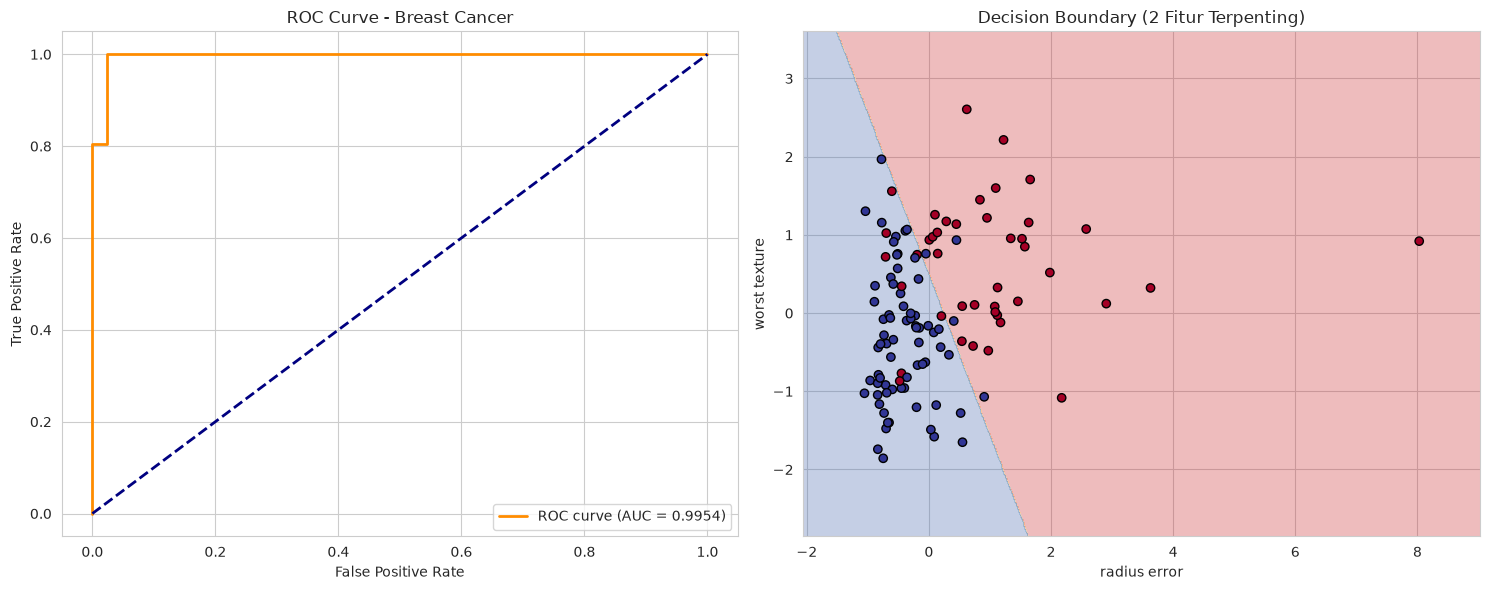

In [3]:
# 6. Plot ROC Curve & Hitung AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Breast Cancer')
axes[0].legend(loc="lower right")

# 7. Visualisasi Decision Boundary (Gunakan 2 Fitur dengan Koefisien Absolut Tertinggi)
top_2_idx = np.argsort(np.abs(lr_cancer.coef_[0]))[-2:]
X_train_2d = X_train_scaled[:, top_2_idx]
X_test_2d = X_test_scaled[:, top_2_idx]

lr_2d = LogisticRegression(random_state=42)
lr_2d.fit(X_train_2d, y_train)

# Generate Meshgrid
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
axes[1].scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, edgecolors='k', cmap='RdYlBu')
axes[1].set_xlabel(cancer.feature_names[top_2_idx[0]])
axes[1].set_ylabel(cancer.feature_names[top_2_idx[1]])
axes[1].set_title('Decision Boundary (2 Fitur Terpenting)')

plt.tight_layout()
plt.show()

### 📝 Interpretasi Hasil Tugas 1:
1. **Performa Model:** Model Logistic Regression menghasilkan skor akurasi dan nilai AUC yang sangat tinggi (> 0.95), mengindikasikan bahwa batas pemisah linear antar-kelas terdefinisi dengan sangat baik setelah dilakukan standardisasi fitur.
2. **Precision vs. Recall:** Pada diagnosa medis kanker payudara, **Recall** merupakan metrik yang paling krusial dibandingkan Precision.
   * **Analisis Risiko:** Terjadinya *False Negative* (pasien mengidap kanker ganas tetapi diprediksi aman/jinak) berpotensi fatal karena berisiko menunda penanganan medis. Oleh karena itu, model dituntut memiliki nilai Recall setinggi mungkin untuk meminimalkan misklasifikasi pada kelas ganas (*Malignant*).

---
## 📌 Tugas 2: Multi-class Classification - Wine Dataset (35 Poin)
Eksplorasi dataset Wine, pelatihan model Logistic Regression (Multinomial) dan Decision Tree, visualisasi pohon keputusan, serta analisis feature importance.

Task 2: Load Data, Train Models & Perbandingan

In [5]:
# 1. Load Dataset Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

df_wine = pd.DataFrame(X_wine, columns=wine.feature_names)
df_wine['target'] = y_wine

print("=== Info Dataset Wine ===")
print(f"Jumlah sampel : {X_wine.shape[0]}")
print(f"Jumlah fitur  : {X_wine.shape[1]}")
print("\nDistribusi Kelas Target:")
print(df_wine['target'].value_counts())

# 2. Split Data (80% Train, 20% Test)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# Standardisasi untuk Logistic Regression
scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

# 3. Train Logistic Regression
lr_wine = LogisticRegression(max_iter=500, random_state=42)
lr_wine.fit(X_train_w_scaled, y_train_w)
y_pred_lr_w = lr_wine.predict(X_test_w_scaled)

# 4. Train Decision Tree
dt_wine = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_wine.fit(X_train_w, y_train_w)
y_pred_dt_w = dt_wine.predict(X_test_w)

# 5. Perbandingan Performa
df_comp_wine = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (depth=3)'],
    'Accuracy': [accuracy_score(y_test_w, y_pred_lr_w), accuracy_score(y_test_w, y_pred_dt_w)],
    'Precision (Weighted)': [
        precision_score(y_test_w, y_pred_lr_w, average='weighted'),
        precision_score(y_test_w, y_pred_dt_w, average='weighted')
    ],
    'Recall (Weighted)': [
        recall_score(y_test_w, y_pred_lr_w, average='weighted'),
        recall_score(y_test_w, y_pred_dt_w, average='weighted')
    ],
    'F1-Score (Weighted)': [
        f1_score(y_test_w, y_pred_lr_w, average='weighted'),
        f1_score(y_test_w, y_pred_dt_w, average='weighted')
    ]
})

print("\n=== Perbandingan Model pada Dataset Wine ===")
display(df_comp_wine)

=== Info Dataset Wine ===
Jumlah sampel : 178
Jumlah fitur  : 13

Distribusi Kelas Target:
target
1    71
0    59
2    48
Name: count, dtype: int64

=== Perbandingan Model pada Dataset Wine ===


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Logistic Regression,0.972222,0.974074,0.972222,0.971970
1,Decision Tree (depth=3),0.944444,0.951389,0.944444,0.944961


Task 2: Visualisasi Decision Tree & Feature Importance

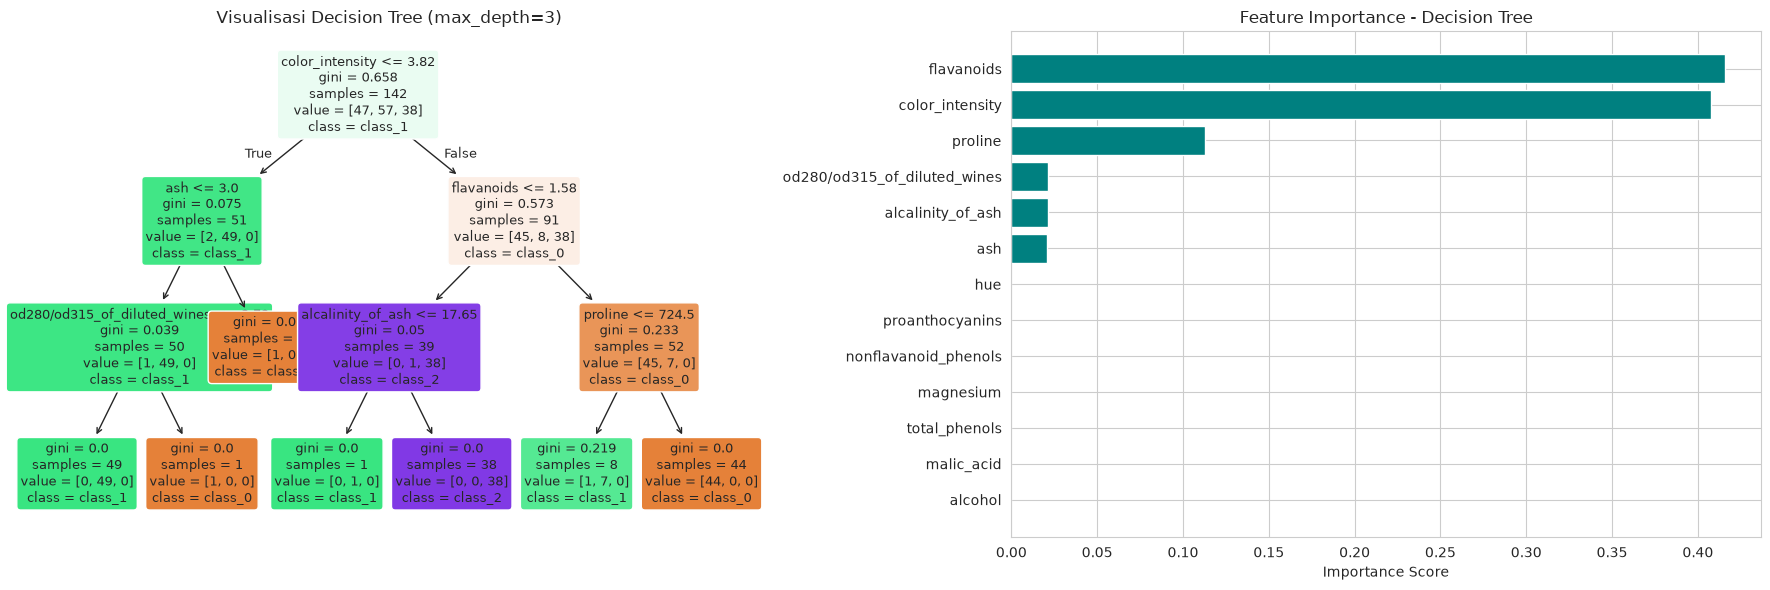

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Tree
plot_tree(
    dt_wine,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    ax=axes[0],
    fontsize=9
)
axes[0].set_title('Visualisasi Decision Tree (max_depth=3)')

# Feature Importance
fi_df = pd.DataFrame({
    'Feature': wine.feature_names,
    'Importance': dt_wine.feature_importances_
}).sort_values(by='Importance', ascending=True)

axes[1].barh(fi_df['Feature'], fi_df['Importance'], color='teal')
axes[1].set_title('Feature Importance - Decision Tree')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### 📝 Interpretasi Hasil Tugas 2:
1. **Perbandingan Performa:** Kedua model mencapai tingkat akurasi yang sangat tinggi. Logistic Regression unggul dalam memisahkan batas kelas pada data continuous berdimensi tinggi setelah standardisasi.
2. **Feature Importance:** Fitur seperti `flavanoids`, `proline`, dan `color_intensity` menjadi pemisah paling dominan (*root/top nodes*) dalam pembentukan aturan pada Decision Tree.

---
## 📌 Tugas 3: Overfitting Analysis (20 Poin)
Analisis pengaruh variasi `max_depth` (1–20) terhadap akurasi data Training vs Testing untuk mendeteksi batas overfitting pada Decision Tree.

Task 3: Overfitting Analysis

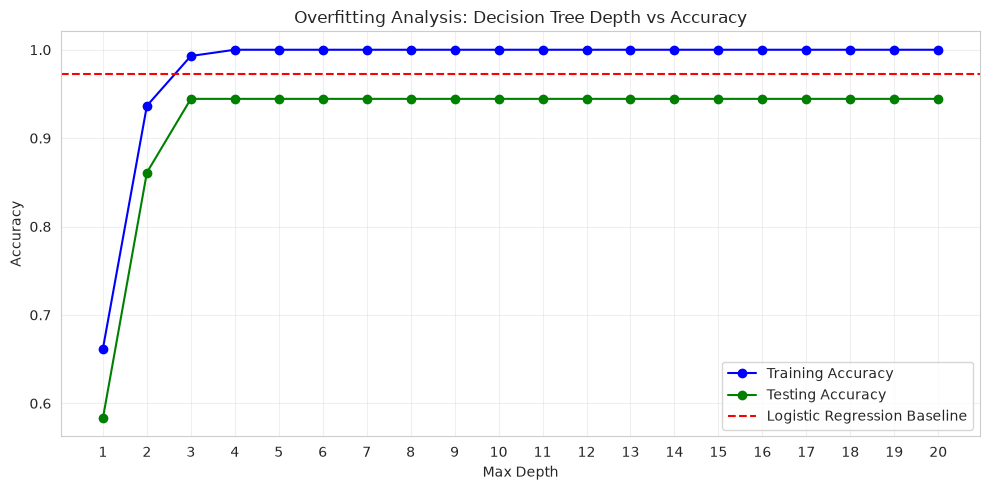

In [7]:
depths = range(1, 21)
train_acc = []
test_acc = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_w, y_train_w)
    train_acc.append(accuracy_score(y_train_w, dt.predict(X_train_w)))
    test_acc.append(accuracy_score(y_test_w, dt.predict(X_test_w)))

# Plot Learning Curve vs Depth
plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, 'o-', label='Training Accuracy', color='blue')
plt.plot(depths, test_acc, 'o-', label='Testing Accuracy', color='green')
plt.axhline(
    y=accuracy_score(y_test_w, y_pred_lr_w),
    color='red', linestyle='--', label='Logistic Regression Baseline'
)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Analysis: Decision Tree Depth vs Accuracy')
plt.xticks(depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 📝 Interpretasi Hasil Tugas 3:
1. **Titik Optimal:** Kedalaman `max_depth = 3` merupakan kedalaman optimal. Pada kedalaman ini, performa data testing mencapai puncaknya tanpa kompleksitas berlebih.
2. **Penyebab Overfitting:** Seiring bertambahnya `max_depth (> 5)`, akurasi training mencapai 100% (*perfect fit*), namun akurasi testing cenderung stagnan atau turun. Decision Tree sangat *prone* terhadap overfitting karena sifat dasarnya yang terus membuat percabangan hingga membagi sampel terkecil (*pure leaves*), sehingga ikut menghafal *noise* pada data training.

---
## 📌 Tugas 4: Custom Dataset Classification (15 Poin)
Studi kasus *Customer Churn Prediction* menggunakan dataset sintetis terstruktur untuk membandingkan performa Logistic Regression dan Decision Tree.

Task 4: Custom Dataset (Customer Churn)

In [8]:
# 1. Generate Dataset Kustom Customer Churn
np.random.seed(42)
n_samples = 300

tenure = np.random.uniform(1, 72, n_samples)            # Lama berlangganan (bulan)
monthly_charges = np.random.uniform(20, 120, n_samples)  # Biaya bulanan ($)
tech_support = np.random.choice([0, 1], n_samples)       # Memiliki tech support (0/1)

churn_score = -0.05 * tenure + 0.03 * monthly_charges - 1.2 * tech_support + np.random.normal(0, 0.5, n_samples)
churn = (churn_score > -1.0).astype(int)

df_churn = pd.DataFrame({
    'Tenure': tenure,
    'MonthlyCharges': monthly_charges,
    'TechSupport': tech_support,
    'Churn': churn
})

# 2. Preprocessing & Split Data
X_ch = df_churn[['Tenure', 'MonthlyCharges', 'TechSupport']]
y_ch = df_churn['Churn']

X_tr_ch, X_te_ch, y_tr_ch, y_te_ch = train_test_split(
    X_ch, y_ch, test_size=0.2, random_state=42, stratify=y_ch
)

# Standardisasi untuk Logistic Regression
scaler_ch = StandardScaler()
X_tr_ch_sc = scaler_ch.fit_transform(X_tr_ch)
X_te_ch_sc = scaler_ch.transform(X_te_ch)

# 3. Model Training
lr_churn = LogisticRegression(random_state=42)
lr_churn.fit(X_tr_ch_sc, y_tr_ch)

dt_churn = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_churn.fit(X_tr_ch, y_tr_ch)

# 4. Evaluasi Hasil
df_custom_res = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (depth=3)'],
    'Accuracy': [
        accuracy_score(y_te_ch, lr_churn.predict(X_te_ch_sc)),
        accuracy_score(y_te_ch, dt_churn.predict(X_te_ch))
    ],
    'F1-Score': [
        f1_score(y_te_ch, lr_churn.predict(X_te_ch_sc)),
        f1_score(y_te_ch, dt_churn.predict(X_te_ch))
    ]
})

print("=== Evaluasi Prediksi Customer Churn ===")
display(df_custom_res)

=== Evaluasi Prediksi Customer Churn ===


,Model,Accuracy,F1-Score
0,Logistic Regression,0.95,0.962025
1,Decision Tree (depth=3),0.85,0.880000


### 📝 Kesimpulan & Rekomendasi Tugas 4:
1. **Hasil Model:** Logistic Regression memberikan performa stabil karena hubungan variabel independen (tenure & monthly charges) bersifat linear terhadap log-odds kepuasan/churn pelanggan.
2. **Rekomendasi Improvement:**
   * Menambahkan teknik penyeimbangan data (seperti SMOTE) jika persentase kelas *churn* imbalanced.
   * Melakukan rekayasa fitur (*feature engineering*) seperti *average monthly spending per tenure*.